# Logistic Regression

In [1]:
import sys
import os
import pandas as pd

# Agregar el directorio raiz al PYTHONPATH
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
from src.trainers.utils import build_datasets
from constants.constants_twitter import TWITTER_DATASET_TRAIN_PATH

dataset_train, dataset_test, dataset_val = build_datasets(
    TWITTER_DATASET_TRAIN_PATH,
    test_size=0.3,
    val_size=0.5, # 0.5 de 0.3    
    random_state=42,
    undersampling=True
)
print(dataset_train.shape)
print(dataset_test.shape)
print(dataset_val.shape)

(36924, 2)
(7912, 2)
(7913, 2)


## Hiperparámetros

In [3]:
import numpy as np
from sklearn.model_selection import ParameterGrid

param_grid_l1 = {
    "penalty": ["l1"],
    "solver": ["saga"],
    "vectorizer": ["tfidf", "bow"],
    "C": np.logspace(-1, 0.7, 5)
}

param_grid_l2 = {
    "penalty": ["l2"],
    "solver": ["lbfgs", "saga"],
    "vectorizer": ["tfidf", "bow"],
    "C": np.logspace(-1, 0.7, 5)
}

combinaciones_l1 = list(ParameterGrid(param_grid_l1))
combinaciones_l2 = list(ParameterGrid(param_grid_l2))
combinaciones = combinaciones_l1 + combinaciones_l2
for idx, comb in enumerate(combinaciones, 1):
    print(f"Model {idx}: {comb}")

Model 1: {'C': 0.1, 'penalty': 'l1', 'solver': 'saga', 'vectorizer': 'tfidf'}
Model 2: {'C': 0.1, 'penalty': 'l1', 'solver': 'saga', 'vectorizer': 'bow'}
Model 3: {'C': 0.26607250597988097, 'penalty': 'l1', 'solver': 'saga', 'vectorizer': 'tfidf'}
Model 4: {'C': 0.26607250597988097, 'penalty': 'l1', 'solver': 'saga', 'vectorizer': 'bow'}
Model 5: {'C': 0.7079457843841379, 'penalty': 'l1', 'solver': 'saga', 'vectorizer': 'tfidf'}
Model 6: {'C': 0.7079457843841379, 'penalty': 'l1', 'solver': 'saga', 'vectorizer': 'bow'}
Model 7: {'C': 1.8836490894898001, 'penalty': 'l1', 'solver': 'saga', 'vectorizer': 'tfidf'}
Model 8: {'C': 1.8836490894898001, 'penalty': 'l1', 'solver': 'saga', 'vectorizer': 'bow'}
Model 9: {'C': 5.011872336272722, 'penalty': 'l1', 'solver': 'saga', 'vectorizer': 'tfidf'}
Model 10: {'C': 5.011872336272722, 'penalty': 'l1', 'solver': 'saga', 'vectorizer': 'bow'}
Model 11: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs', 'vectorizer': 'tfidf'}
Model 12: {'C': 0.1, 'penalty

## Entrenar modelos

In [4]:
from src.trainers.train_lr import train_lr
from src.trainers.utils import save_model, save_metrics
from constants.constants_twitter import LR_METRICS_PATH, LR_MODEL_DIR

best_accuracy = -1
for idx, param in enumerate(combinaciones, 1):
    pipeline, metrics = train_lr(
        dataset_train, dataset_val,
        vec=param['vectorizer'], penalty=param['penalty'], C=param['C'], solver=param['solver'], max_iter=200
    )
    metrics['name'] = f"model_{idx}"
    print(f"[{metrics['name']} Acc: {metrics['accuracy']:.4f}] {param}")
    save_metrics(metrics, LR_METRICS_PATH)
    save_model(pipeline, os.path.join(LR_MODEL_DIR, f"{metrics['name']}.pkl"))
    if metrics['accuracy'] > best_accuracy:
        best_accuracy = metrics['accuracy']
        print(f"New best accuracy ({metrics['name']})\n")
        save_model(pipeline, os.path.join(LR_MODEL_DIR, "best_model.pkl"))

c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[model_1 Acc: 0.6290] {'C': 0.1, 'penalty': 'l1', 'solver': 'saga', 'vectorizer': 'tfidf'}
New best accuracy (model_1)



c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[model_2 Acc: 0.6680] {'C': 0.1, 'penalty': 'l1', 'solver': 'saga', 'vectorizer': 'bow'}
New best accuracy (model_2)



c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


...

c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[model_29 Acc: 0.8360] {'C': 5.011872336272722, 'penalty': 'l2', 'solver': 'saga', 'vectorizer': 'tfidf'}


c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[model_30 Acc: 0.7387] {'C': 5.011872336272722, 'penalty': 'l2', 'solver': 'saga', 'vectorizer': 'bow'}


c:\Users\Diego\anaconda3\envs\tensorflow_pytorch\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Modelo con mayor accurary

In [5]:
# Seleccionar los hiperparámetros que generan mayor accuracy
df_metrics = pd.read_csv(LR_METRICS_PATH)

best_acc = df_metrics.loc[df_metrics['accuracy'].idxmax()]
print(best_acc)

accuracy           0.84456
recall             0.84456
precision         0.845231
f1_score          0.844623
model                   LR
vectorizer             BOW
penalty                 l2
regularization    5.011872
max_iter               200
solver               lbfgs
vocab_size           11819
train_time        3.373161
name              model_28
Name: 27, dtype: object


Cargando modelo: c:\Users\Diego\Desktop\sentiment_analysis\models\twitter\classifiers\lr\best_model.pkl

Logistic Regression
Reporte de clasificacion
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      2661
           1       0.81      0.86      0.83      2508
           2       0.85      0.82      0.83      2743

    accuracy                           0.83      7912
   macro avg       0.83      0.83      0.83      7912
weighted avg       0.83      0.83      0.83      7912

Matriz de confusión


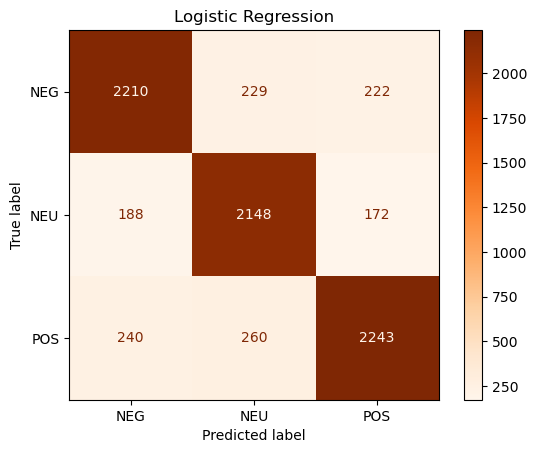

{'accuracy': 0.8343023255813954,
 'recall': 0.834301889031012,
 'precision': 0.8348973337945446,
 'f1_score': 0.8343113547463771}

In [6]:
from src.trainers.utils import evaluate_model
from src.trainers.utils import load_model

# Evaluar modelo con datos de prueba
pipeline = load_model(os.path.join(LR_MODEL_DIR, "best_model.pkl"))
metrics = evaluate_model(pipeline, dataset_test, title="Logistic Regression")
display(metrics)